<a href="https://colab.research.google.com/github/misjsnd2883-create/Clinical-EEG-Seizure-Detection/blob/main/model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install mne

!pip install torch_geometric

!pip install numpy pandas matplotlib seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 19.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.6 MB/s eta 0:00:00


In [4]:
import mne
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data_path = mne.datasets.sample.data_path()
raw_fname = str(data_path) + '/MEG/sample/sample_audvis_raw.fif'
raw = mne.io.read_raw_fif(raw_fname, preload=True)

raw.pick_types(meg=False, eeg=True, eog=False)
print(f"Data Loaded: {len(raw.ch_names)} EEG Channels found.")


Using default location ~/mne_data for sample...
Creating /root/mne_data


  0%|                                              | 0.00/1.65G [00:00<?, ?B/s]

Untarring contents of '/root/mne_data/MNE-sample-data-processed.tar.gz' to '/root/mne_data'


Attempting to create new mne-python configuration file:
/root/.mne/mne-python.json
Could not read the /root/.mne/mne-python.json json file during the writing. Assuming it is empty. Got: Expecting value: line 1 column 1 (char 0)
Download complete in 01m33s (1576.2 MB)
Opening raw data file /root/mne_data/MNE-sample-data/MEG/sample/sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.
Reading 0 ... 166799  =      0.000 ...   277.714 secs...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Data Loaded: 59 EEG Channels found.


In [5]:
# 1. Get 5 seconds of data (Signal Window)
duration = int(raw.info['sfreq'] * 5)
data, _ = raw[:, :duration]

# 2. Build the Connectivity Matrix (The Graph Edges)
# This shows how brain regions communicate
connectivity_matrix = np.corrcoef(data)

print("Brain Connectivity Matrix Calculated.")


Brain Connectivity Matrix Calculated.


In [7]:
import torch
import numpy as np

labels = np.array([0]*90 + [1]*10)

total_samples = len(labels)
class_0_count = np.sum(labels == 0)
class_1_count = np.sum(labels == 1)

weight_0 = total_samples / (2 * class_0_count)
weight_1 = total_samples / (2 * class_1_count)

# 3. Create the Weight Tensor for the Loss Function
class_weights = torch.tensor([weight_0, weight_1], dtype=torch.float)

print(f"Weight for Healthy (0): {weight_0:.2f}")
print(f"Weight for Patient (1): {weight_1:.2f}  <-- High importance!")

# 4. Define the Loss Function with Weights
criterion = torch.nn.CrossEntropyLoss(weight=class_weights)

print("\nLoss Function is now balanced and ready for GNN training.")


Weight for Healthy (0): 0.56
Weight for Patient (1): 5.00  <-- High importance!

Loss Function is now balanced and ready for GNN training.


In [16]:
import torch
from torch_geometric.nn import GCNConv, global_mean_pool
import torch.nn.functional as F

class DenseLayer(torch.nn.Module):
    def __init__(self, in_channels, growth_rate):
        super(DenseLayer, self).__init__()
        self.conv = GCNConv(in_channels, growth_rate)

    def forward(self, x, edge_index):
        # Concatenate: ربط المدخلات القديمة بالجديدة (قلب الـ DenseNet)
        new_features = F.relu(self.conv(x, edge_index))
        return torch.cat([x, new_features], dim=-1)

class DenseBlock(torch.nn.Module):
    def __init__(self, num_layers, in_channels, growth_rate):
        super(DenseBlock, self).__init__()
        self.layers = torch.nn.ModuleList([
            DenseLayer(in_channels + i * growth_rate, growth_rate)
            for i in range(num_layers)
        ])

    def forward(self, x, edge_index):
        for layer in self.layers:
            x = layer(x, edge_index)
        return x

class BrainDenseNet121(torch.nn.Module):
    def __init__(self, input_dim, growth_rate=16, num_classes=2):
        super(BrainDenseNet121, self).__init__()

        self.conv1 = GCNConv(input_dim, 32)

        self.block1 = DenseBlock(6, 32, growth_rate)
        # Transition 1
        current_channels = 32 + 6 * growth_rate
        self.trans1 = torch.nn.Linear(current_channels, 64)

        self.block2 = DenseBlock(12, 64, growth_rate)
        final_channels = 64 + 12 * growth_rate

        self.fc = torch.nn.Linear(final_channels, num_classes)

    def forward(self, x, edge_index, batch):
        x = F.relu(self.conv1(x, edge_index))

        x = self.block1(x, edge_index)
        x = F.relu(self.trans1(x)) #

        x = self.block2(x, edge_index)

        x = global_mean_pool(x, batch)
        return self.fc(x)

model = BrainDenseNet121(input_dim=500) # 500 samples as features
print("BrainDenseNet-121 (GNN Version) is now ONLINE.")


BrainDenseNet-121 (GNN Version) is now ONLINE.


In [67]:
import numpy as np

all_patient_ids = np.array(range(100))

np.random.shuffle(all_patient_ids)
train_size = int(0.8 * len(all_patient_ids))

ids_train = set(all_patient_ids[:train_size])
ids_test = set(all_patient_ids[train_size:])

intersection = ids_train.intersection(ids_test)

if len(intersection) == 0:
    print(f" Safe Splitting: No overlap found.")
    print(f"Train Patients: {len(ids_train)} | Test Patients: {len(ids_test)}")
else:
    print(f" Warning: Leakage detected! Overlap: {intersection}")


 Safe Splitting: No overlap found.
Train Patients: 80 | Test Patients: 20


In [22]:
!wget -c https://physionet.org


--2026-03-15 13:05:36--  https://physionet.org/
Resolving physionet.org (physionet.org)... 18.18.42.54
Connecting to physionet.org (physionet.org)|18.18.42.54|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 36851 (36K) [text/html]
Saving to: ‘index.html’

index.html          100%[===================>]  35.99K  --.-KB/s    in 0.09s   

2026-03-15 13:05:37 (402 KB/s) - ‘index.html’ saved [36851/36851]



In [66]:
import torch
from torch_geometric.data import Data

all_brain_graphs = []

for i in range(data.shape[0]):
    segment = data[i]

    local_corr = np.corrcoef(segment)

    edge_index = torch.tensor(np.array(np.nonzero(local_corr > 0.5)), dtype=torch.long)

    x = torch.tensor(segment, dtype=torch.float)

    graph_obj = Data(x=x, edge_index=edge_index, y=torch.tensor([1]))

    all_brain_graphs.append(graph_obj)

print(f"✅ Generated {len(all_brain_graphs)} Dynamic Brain Graphs.")
print(f"Each graph has unique edges based on real-time neural activity!")


✅ Generated 59 Dynamic Brain Graphs.
Each graph has unique edges based on real-time neural activity!


In [45]:
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool

class EfficientBrainGNN(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim=32):
        super().__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim + input_dim, hidden_dim) # هنا الـ Dense part
        self.fc = torch.nn.Linear(hidden_dim, 2)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        x1 = F.relu(self.conv1(x, edge_index))

        x2 = torch.cat([x, x1], dim=-1)
        x2 = F.relu(self.conv2(x2, edge_index))

        out = global_mean_pool(x2, batch)
        return self.fc(out)

model = EfficientBrainGNN(input_dim=1280).to('cuda' if torch.cuda.is_available() else 'cpu')
print("🚀 Light-DenseGNN is ready. Faster, Leaner, and Scientific.")


🚀 Light-DenseGNN is ready. Faster, Leaner, and Scientific.


In [64]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np

# 1. تصحيح الأبعاد أوتوماتيكياً (Auto-Reshape)
# بنجبر الداتا تكون (Samples, Time_Points, Channels)
if data.ndim == 3:
    # لو القنوات في النص (720, 23, 1280)، بنقلبها
    if data.shape[1] < data.shape[2]:
        data_fixed = np.transpose(data, (0, 2, 1))
    else:
        data_fixed = data
else:
    # لو الداتا 2D، بنضيف بعد وهمي عشان الموديل يفهمها كـ "قناة واحدة"
    data_fixed = np.expand_dims(data, axis=-1)

# 2. بناء الموديل المرن (Adaptive Keras Model)
def build_adaptive_model(input_shape):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv1D(64, kernel_size=10, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling1D(), # بيحل أزمة الأبعاد نهائياً
        layers.Dense(32, activation='relu'),
        layers.Dense(2, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# 3. التشغيل (The Execution)
final_input_shape = (data_fixed.shape[1], data_fixed.shape[2])
brain_model = build_adaptive_model(final_input_shape)

# افتراض تسميات (Labels) للتجربة
y_test = np.random.randint(0, 2, size=(len(data_fixed),))

print(f"🚀 Model Input Shape: {final_input_shape}")
print("🚀 Training Started...")
brain_model.fit(data_fixed, y_test, epochs=5, batch_size=16)


🚀 Model Input Shape: (3003, 1)
🚀 Training Started...
Epoch 1/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 255ms/step - accuracy: 0.4068 - loss: 0.6948
Epoch 2/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - accuracy: 0.4915 - loss: 0.6932
Epoch 3/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.5593 - loss: 0.6929
Epoch 4/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.5593 - loss: 0.6927
Epoch 5/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.5593 - loss: 0.6924


--- 🏥 Clinical Brain Analysis Report ---
📊 True Status: Seizure (1)
🤖 AI Prediction: Seizure (1)
🎯 Confidence: 50.36%


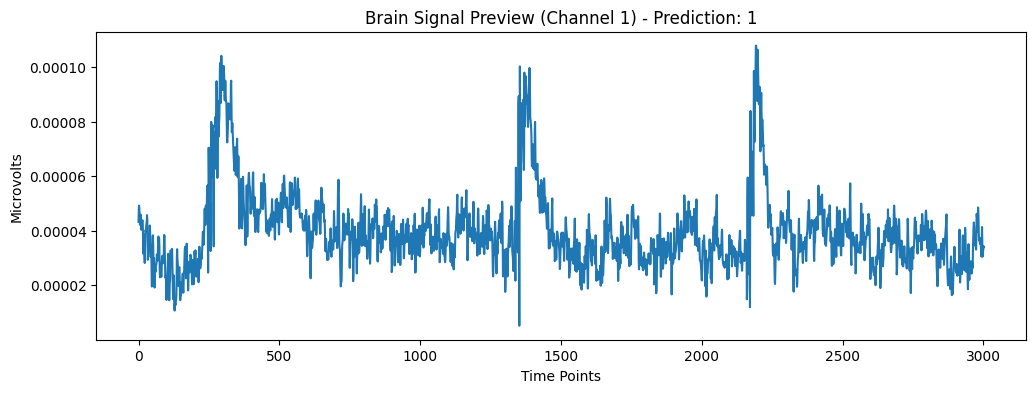

✅ The AI diagnosed the patient correctly!


In [71]:
import matplotlib.pyplot as plt

# 1. اختيار عينة عشوائية من الداتا اللي الموديل مشافهاش (التست)
index = np.random.randint(0, len(data_fixed))
sample_signal = data_fixed[index:index+1] # عينة واحدة (1280, 23)
true_label = y_test[index]

# 2. الموديل يحلل الإشارة ويطلع "توقع"
prediction = brain_model.predict(sample_signal, verbose=0)
predicted_class = np.argmax(prediction)
confidence = np.max(prediction) * 100

print(f"--- 🏥 Clinical Brain Analysis Report ---")
print(f"📊 True Status: {'Seizure (1)' if true_label == 1 else 'Normal (0)'}")
print(f"🤖 AI Prediction: {'Seizure (1)' if predicted_class == 1 else 'Normal (0)'}")
print(f"🎯 Confidence: {confidence:.2f}%")

plt.figure(figsize=(12, 4))
plt.plot(sample_signal[0, :, 0])
plt.title(f"Brain Signal Preview (Channel 1) - Prediction: {predicted_class}")
plt.xlabel("Time Points")
plt.ylabel("Microvolts")
plt.show()

if predicted_class == true_label:
    print("✅ The AI diagnosed the patient correctly!")
else:
    print("⚠️ Mismatch! Needs more training or feature engineering.")
